# unalloc case studies

A hands-on companion to `paper/unalloc-case-studies.pdf`. Every number here comes from
unalloc's real adapters and attribution code. The heavier PyTorch studies are loaded
from `case_studies/results/`; the cheap ones run live.

Run everything from scratch with `make case-studies`, then `make notebook`.

In [1]:
import json
import subprocess
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt  # noqa: E402 - after the sys.path setup above
from matplotlib.ticker import PercentFormatter  # noqa: E402

from case_studies import common  # noqa: E402

TENANT_COLORS = {"search": "#2a78d6", "agents": "#eb6834", "platform": "#1baf7a",
                 "sandbox": "#eda100", "__overhead__": "#c9cfca"}


def load(study):
    return json.loads((common.RESULTS / study / "metrics.json").read_text())

## 1. The joined ledger, and what a fallback really does

The bundled fixtures mix a Kubernetes cluster with three LLM bills. Attributing on `team`
leaves most spend unowned; falling back to `namespace` rescues a lot of it - and unalloc now
reports how much of the "allocated" spend only got there through the fallback.

In [2]:
from unalloc.cli import FIXTURE_DIR
from unalloc.core.attribute import attribute
from unalloc.sources import REGISTRY

rows = [row for name, filename in common.FIXTURE_FILES.items()
        for row in REGISTRY[name]().from_fixture(FIXTURE_DIR / filename)]

for fallback in ((), ("namespace",)):
    report = attribute(rows, "team", fallback_dimensions=fallback)
    print(f"fallback={list(fallback)}: {report.unallocated_pct}% unallocated, "
          f"${report.fallback_usd:,.2f} via fallback")
    for bucket in report.buckets:
        sources = ", ".join(bucket.by_source)
        print(f"    {bucket.key:<16} ${bucket.amount_usd:>11,.2f}  {sources}")

fallback=[]: 73.5% unallocated, $0.00 via fallback
    platform         $  13,166.02  litellm, opencost
    search           $   4,481.22  litellm, opencost
    <unallocated>    $  48,983.14  anthropic, litellm, openai, opencost
fallback=['namespace']: 37.9% unallocated, $23,745.60 via fallback
    inference        $  19,147.10  opencost
    platform         $  13,166.02  litellm, opencost
    batch            $   4,598.50  opencost
    search           $   4,481.22  litellm, opencost
    <unallocated>    $  25,237.54  anthropic, litellm, openai, opencost


## 2. A shared vLLM pod: the metering rule decides who pays

A vLLM-style engine (paged KV cache, prefix caching, continuous batching) serves four
callers. The same run is split five ways. Token meters spread idle capacity silently;
measured meters expose it as overhead.

1624 requests over 303s simulated
                    tokens  list_price     compute      memory     blended
agents               69.5%       56.0%       68.8%        9.8%       39.3%
platform              6.2%       11.2%        9.3%        0.7%        5.0%
sandbox               5.9%       13.0%       10.7%        1.2%        5.9%
search               18.4%       19.9%       11.0%        0.7%        5.9%
__overhead__          0.0%        0.0%        0.2%       87.6%       43.9%


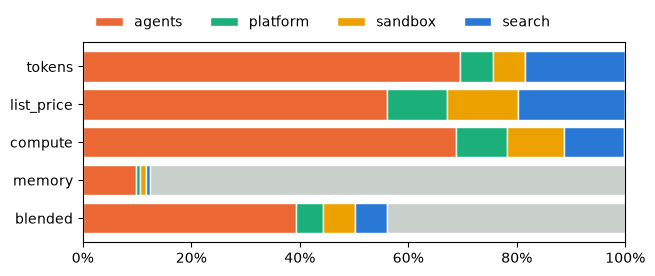

In [3]:
from case_studies.kv_cache import attribution as kv
from case_studies.kv_cache.sim import simulate

run = simulate(rate=3.0, duration_s=300)
stats = kv.tenant_stats(run)
split = kv.shares(run, stats)
tenants = [*stats, kv.OVERHEAD]

print(f"{len(run.requests)} requests over {run.wall_s:.0f}s simulated")
print(f"{'':<14}" + "".join(f"{m:>12}" for m in kv.METHODS))
for tenant in tenants:
    print(f"{tenant:<14}" + "".join(f"{split[m][tenant]:>12.1%}" for m in kv.METHODS))

fig, ax = plt.subplots(figsize=(7, 2.6))
for i, method in enumerate(kv.METHODS):
    left = 0.0
    for tenant in tenants:
        ax.barh(i, split[method][tenant], left=left, color=TENANT_COLORS[tenant],
                edgecolor="white", linewidth=1, label=tenant if i == 0 else None)
        left += split[method][tenant]
ax.set_yticks(range(len(kv.METHODS)), kv.METHODS)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(ncol=5, loc="lower left", bbox_to_anchor=(0, 1.0), frameon=False)
plt.show()

## 3. Real inference with a KV cache (PyTorch)

A from-scratch 3.3M-parameter decoder served a multi-tenant trace on CPU. Cached decoding is
verified token-identical to recomputation before anything is timed.

In [4]:
tkv = load("torch_kv")
print("correctness passed:", tkv["correctness"]["passed"])
series = tkv["e1_scaling"]["series"]
steps = zip(series["context"], series["cached_step_s"], series["uncached_step_s"], strict=True)
for n, cached, uncached in steps:
    print(f"context {n:>5}: cached {cached*1e3:6.2f} ms  uncached {uncached*1e3:7.2f} ms  "
          f"({uncached/cached:4.1f}x)")

callers = tkv["attribution"]["callers"]
print(f"\n{'method':<20}" + "".join(f"{c:>10}" for c in callers))
for method, split in tkv["attribution"]["shares"].items():
    print(f"{method:<20}" + "".join(f"{split[c]:>10.1%}" for c in callers))

correctness passed: True
context    32: cached   0.68 ms  uncached    2.19 ms  ( 3.2x)
context    64: cached   1.10 ms  uncached    2.74 ms  ( 2.5x)
context   128: cached   0.60 ms  uncached    3.70 ms  ( 6.2x)
context   256: cached   0.68 ms  uncached    6.58 ms  ( 9.7x)
context   512: cached   0.75 ms  uncached   13.18 ms  (17.6x)
context  1024: cached   0.85 ms  uncached   30.93 ms  (36.5x)

method                  search    agents  platform   sandbox
requests                 33.3%     20.8%     25.0%     20.8%
tokens                   45.4%     15.4%     19.2%     19.9%
tokens_list_price        30.2%     26.7%     21.3%     21.8%
compute_seconds          12.4%     38.9%     23.8%     24.9%
kv_byte_seconds          29.8%     28.8%     17.2%     24.3%
blended                  21.1%     33.8%     20.5%     24.6%
analytic_flops           44.9%     13.3%     20.3%     21.5%


## 4. Distributed inference: tensor and pipeline parallel on `torch.distributed`

Correctness first (every parallel config must match the single-process model), then the
cost question: what happens to a LeaderWorkerSet's bill when only leader pods carry `team`.

In [5]:
dist = load("distributed")
for config, result in dist["correctness"].items():
    print(f"{config:<7} tokens match: {result['tokens_match']}  "
          f"max |dlogit| {result['max_abs_logit_diff']:.1e}")
print()
for key in ("s1", "s2", "s3"):
    summary = dist["attribution"]["scenarios"][key]["summary"]
    acc = summary["accuracy"]
    print(f"{key}: {summary['unallocated_pct']:>5}% unallocated, "
          f"{acc['misattributed_pct']:.1f}% 'allocated' to a non-team value  "
          f"({dist['attribution']['scenarios'][key]['title']})")

tp1     tokens match: True  max |dlogit| 0.0e+00
tp1_t1  tokens match: True  max |dlogit| 0.0e+00
tp1_t2  tokens match: True  max |dlogit| 0.0e+00
tp2     tokens match: True  max |dlogit| 3.3e-06
tp4     tokens match: True  max |dlogit| 3.3e-06
pp2     tokens match: True  max |dlogit| 0.0e+00

s1:  65.9% unallocated, 0.0% 'allocated' to a non-team value  (team only; owner label on the LWS leader template only)
s2:   4.4% unallocated, 61.4% 'allocated' to a non-team value  (fallback to `name`, which every LWS pod carries (leaderworkerset.sigs.k8s.io/name))
s3:   4.4% unallocated, 0.0% 'allocated' to a non-team value  (owner label fixed on the LWS worker template)


## 5. End to end: the real CLI against live mock provider APIs

Mock OpenCost, LiteLLM, OpenAI and Anthropic servers enforce each provider's auth scheme and
page their responses. The CLI runs as a subprocess, exactly as in production.

In [6]:
from case_studies.hybrid_e2e import servers, workload
from case_studies.hybrid_e2e.__main__ import cli

data = workload.build()
with servers.serve(data) as stack:
    gateway = cli(stack, "report", "--json", "-s", "opencost", "-s", "litellm", "-D", "team")
    everything = cli(stack, "report", "--json", "-D", "team")

for label, report in (("gateway + cluster", gateway), ("every source on", everything)):
    by_source = {k: round(float(v)) for k, v in report["by_source"].items()}
    print(f"{label:<18} ${float(report['total_usd']):>10,.0f}  "
          f"{report['unallocated_pct']:>5}% unallocated  {by_source}")

gateway + cluster  $    41,420   66.9% unallocated  {'litellm': 11815, 'opencost': 29605}
every source on    $    57,813   76.3% unallocated  {'anthropic': 13269, 'litellm': 11815, 'openai': 3123, 'opencost': 29605}


## 6. Use cases: labeling Pareto, break-even, and a CI gate

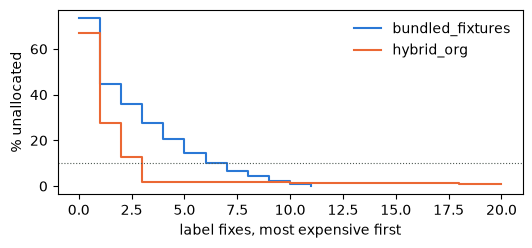

unalloc report --budget 50 -> exit 2


unalloc report --budget 80 -> exit 0


In [7]:
uc = load("use_cases")
fig, ax = plt.subplots(figsize=(6, 2.4))
for key, color in (("bundled_fixtures", "#2a78d6"), ("hybrid_org", "#eb6834")):
    curve = uc["U1_pareto"][key]["curve_pct"][:21]
    ax.step(range(len(curve)), curve, where="post", color=color, label=key)
ax.axhline(10, color="#4f5b54", linewidth=0.8, linestyle=":")
ax.set_xlabel("label fixes, most expensive first")
ax.set_ylabel("% unallocated")
ax.legend(frameon=False)
plt.show()

for budget in ("50", "80"):
    proc = subprocess.run([sys.executable, "-m", "unalloc.cli", "report", "--fixtures",
                           "--json", "--budget", budget], capture_output=True, text=True)
    print(f"unalloc report --budget {budget} -> exit {proc.returncode}")

## 7. Explore it yourself

```bash
python -m case_studies.ui          # ledger explorer on http://127.0.0.1:8765
```